### Estudio de los límites superiores del número de transacciones usado para el entrenamiento de knn y modelos de regresión

In [1]:
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path
import sys

Si se hace estudio de distintas confiuraciones o parámetros de KNN o modelos de predicción debe ajustarse la ruta de los datos correspondiente y las gráficas que mejor se ajustan a cada caso:

In [2]:
base_path = Path.cwd().parent / "data" / "resultados_analisis"
ruta_json = base_path / "metricsKNNv3.json"
ruta_joblib = base_path / "todos_los_modelosv2.joblib"

In [4]:
with open(ruta_json, 'r') as f:
    data_knn = json.load(f)

In [5]:
print(f'Contrato: {data_knn['contrato']}, Signatura  {data_knn['signatura']}, con {data_knn['nº transacciones']} transacciones en total')

Contrato: 0xdac17f958d2ee523a2206206994597c13d831ec7, Signatura  0xa9059cbb, con 2369658 transacciones en total


### KNN

In [35]:
df_plot = pd.DataFrame(data_knn['metricas'])

df_plot['n_samples'] = data_knn['divisiones']
df_plot['tiempo'] = data_knn['tiempos']

#print(df_plot[['n_samples','tiempo', 'exact_match_ratio', 'reliability_score', 'global_r2']].head())

#### Ejecutar para estudio de k para KNN

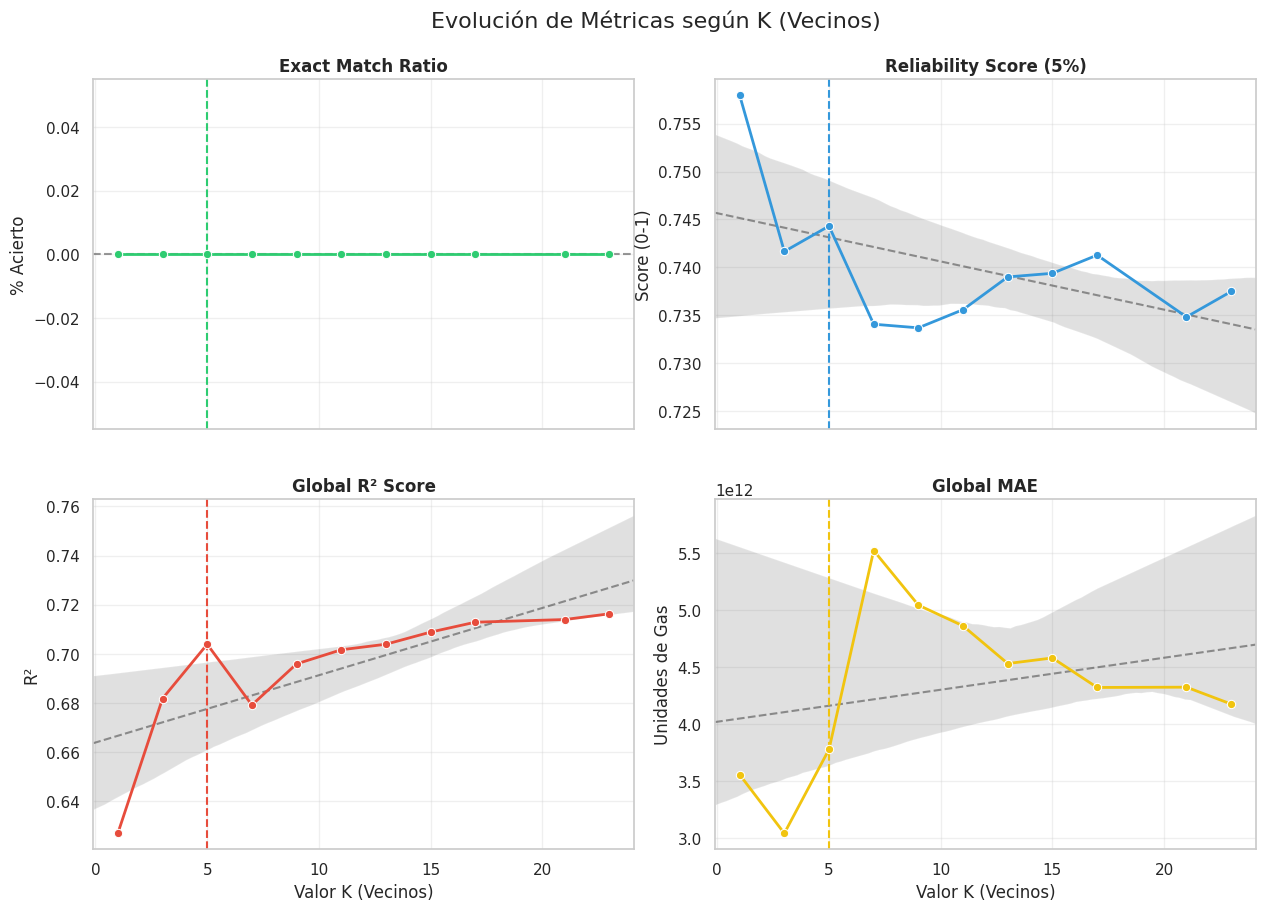

In [36]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.2, wspace=0.15)

colors = ["#2ecc71", "#3498db", "#e74c3c", "#f1c40f"]
metrics = ['exact_match_ratio', 'reliability_score', 'global_r2', 'global_mae']
titles = [
    'Exact Match Ratio',
    'Reliability Score (5%)',
    'Global R² Score',
    'Global MAE'
]
ylabels = ['% Acierto', 'Score (0-1)', 'R²', 'Unidades de Gas']

for i, ax in enumerate(axes.flat):
    m = metrics[i]
    
    sns.lineplot(ax=ax, data=df_plot, x='n_samples', y=m, marker='o', 
                 color=colors[i], linewidth=2, zorder=3)
    sns.regplot(ax=ax, data=df_plot, x='n_samples', y=m, 
                scatter=False, color=".2", 
                line_kws={"ls": "--", "lw": 1.5, "alpha": 0.5},
                truncate=False)

    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabels[i])
    ax.set_xlabel('Valor K (Vecinos)') 
    ax.axvline(x=5, color=colors[i], linestyle='--', linewidth=1.5, label='5', zorder=2)
    ax.grid(True, which="both", ls="-", alpha=0.3)

plt.suptitle(f"Evolución de Métricas según K (Vecinos)", 
             fontsize=16, y=0.95)

plt.show()

#### Ejecutar para estudio de tamaño dataset KNN

/home/anarod/.cache/pypoetry/virtualenvs/tfg-YRquDgB4-py3.12/lib/python3.12/site-packages/seaborn/regression.py:315: RuntimeWarning: invalid value encountered in log
  grid = np.c_[np.ones(len(grid)), np.log(grid)]
/home/anarod/.cache/pypoetry/virtualenvs/tfg-YRquDgB4-py3.12/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


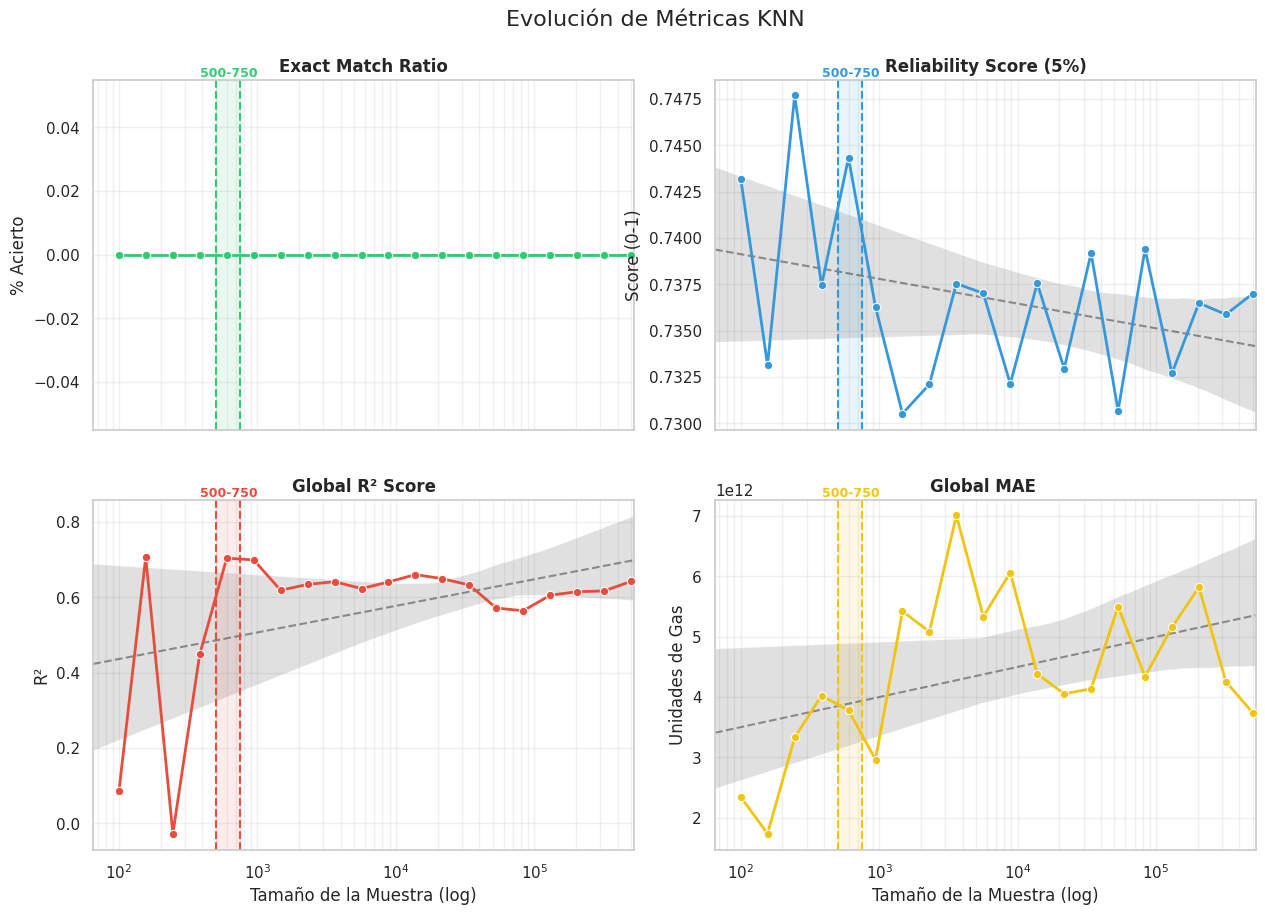

In [13]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.2, wspace=0.15)

colors = ["#2ecc71", "#3498db", "#e74c3c", "#f1c40f"]
metrics = ['exact_match_ratio', 'reliability_score', 'global_r2', 'global_mae']
titles = [
    'Exact Match Ratio',
    'Reliability Score (5%)',
    'Global R² Score',
    'Global MAE '
]
ylabels = ['% Acierto', 'Score (0-1)', 'R²', 'Unidades de Gas']

for i, ax in enumerate(axes.flat):
    m = metrics[i]
    sns.lineplot(ax=ax, data=df_plot, x='n_samples', y=m, marker='o', color=colors[i], linewidth=2, zorder=3)
    sns.regplot(ax=ax, data=df_plot, x='n_samples', y=m, 
                scatter=False, color=".2", 
                line_kws={"ls": "--", "lw": 1.5, "alpha": 0.5},
                logx=True, truncate=False) # logx=True es clave aquí

    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabels[i])
    ax.set_xscale('log')
    ax.set_xlabel('Tamaño de la Muestra (log)')
    ax.grid(True, which="both", ls="-", alpha=0.3)
    ax.axvline(x=500, color=colors[i], linestyle='--', linewidth=1.5, label='Umbral 500', zorder=2)
    ax.axvline(x=750, color=colors[i], linestyle='--', linewidth=1.5, label='Umbral 750', zorder=2)
    ax.axvspan(500, 750, color=colors[i], alpha=0.1, label='Rango 500-750')
    ax.text(625, ax.get_ylim()[1], '500-750', color=colors[i], 
            fontsize=9, fontweight='bold', ha='center', va='bottom')

plt.suptitle(f"Evolución de Métricas KNN", fontsize=16, y=0.95)
plt.show()

#### Estudio en general de KNN

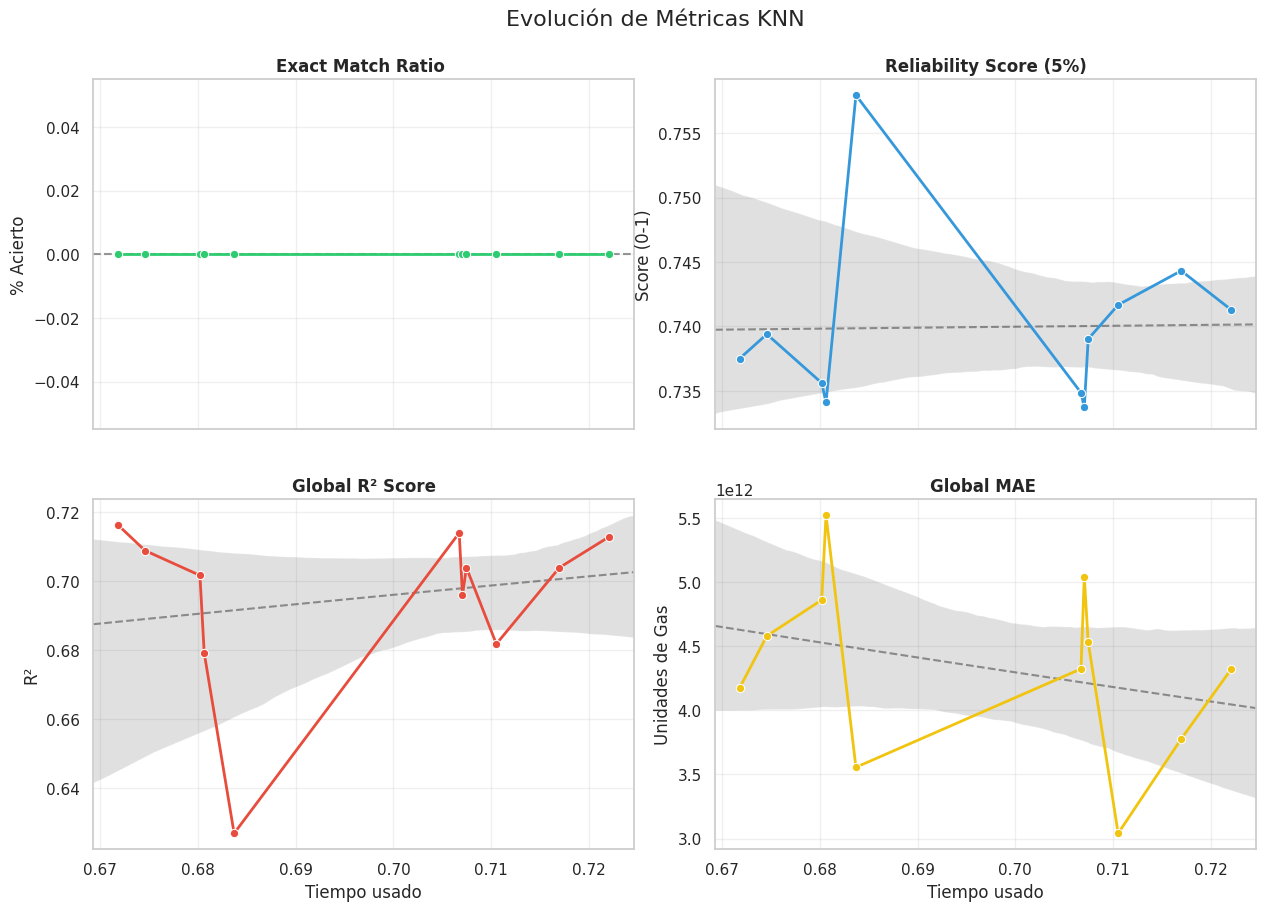

In [15]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.2, wspace=0.15)

colors = ["#2ecc71", "#3498db", "#e74c3c", "#f1c40f"]
metrics = ['exact_match_ratio', 'reliability_score', 'global_r2', 'global_mae']
titles = [
    'Exact Match Ratio ',
    'Reliability Score (5%)',
    'Global R² Score',
    'Global MAE '
]
ylabels = ['% Acierto', 'Score (0-1)', 'R²', 'Unidades de Gas']

for i, ax in enumerate(axes.flat):
    m = metrics[i]
    sns.lineplot(ax=ax, data=df_plot, x='tiempo', y=m, marker='o', color=colors[i], linewidth=2, zorder=3)
    sns.regplot(ax=ax, data=df_plot, x='tiempo', y=m, 
                scatter=False, color=".2", 
                line_kws={"ls": "--", "lw": 1.5, "alpha": 0.5},
                logx=True, truncate=False) # logx=True es clave aquí

    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabels[i])
    #ax.set_xscale('log')
    ax.set_xlabel('Tiempo usado')
    ax.grid(True, which="both", ls="-", alpha=0.3)

plt.suptitle(f"Evolución de Métricas KNN", fontsize=16, y=0.95)
plt.show()

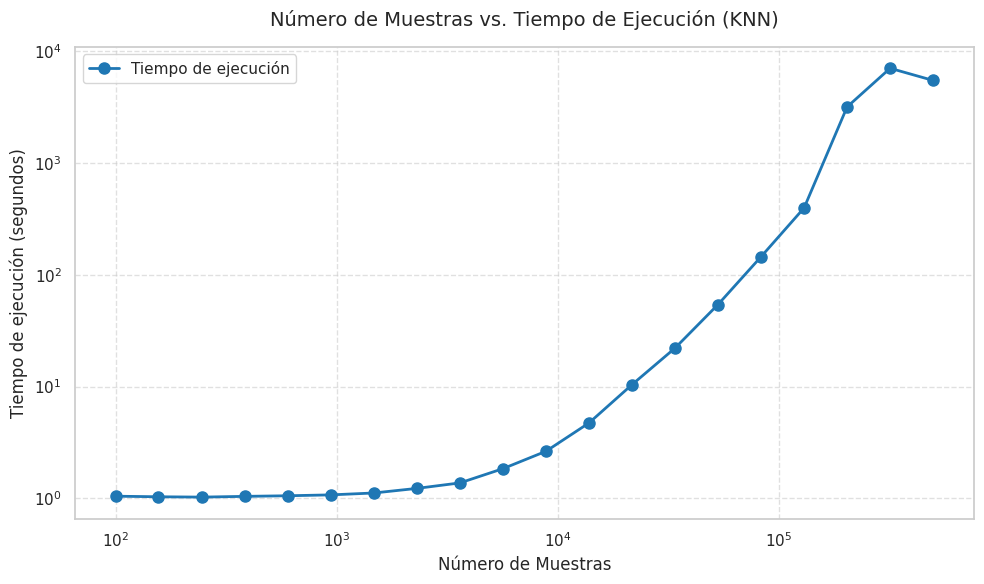

In [16]:
fig, ax = plt.subplots(figsize=(10, 6)) 

ax.plot(
    df_plot['n_samples'], 
    df_plot['tiempo'], 
    marker='o', 
    linestyle='-', 
    color='#1f77b4', 
    linewidth=2, 
    markersize=8,
    label='Tiempo de ejecución'
)
ax.set_title('Número de Muestras vs. Tiempo de Ejecución (KNN)', fontsize=14, pad=15)
ax.set_xlabel('Número de Muestras', fontsize=12)
ax.set_ylabel('Tiempo de ejecución (segundos)', fontsize=12)

# 6. Rejilla, Leyenda y mostrar
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

### Modelado

In [6]:
t_min = 10000
t_max= 200000

In [7]:
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [8]:
models_gas = joblib.load(ruta_joblib)

In [9]:
all_models_metrics = []
i= 0
for limit, info in models_gas.items():
    if limit == 'tiempos': continue
    lista_modelos = info.get('modelos_usados', [])
    for nombre_modelo in lista_modelos:
        try:
            modelo_obj = info['with storage'][nombre_modelo]
            all_models_metrics.append({
                'n_transactions': int(float(limit)),
                'tiempo':models_gas['tiempos'][i],
                'modelo': nombre_modelo,
                'mae': modelo_obj.mae,
                'r2': modelo_obj.r2
            })
        except:
            continue
    i = i+1

df_all = pd.DataFrame(all_models_metrics).sort_values(['tiempo','n_transactions', 'modelo'])

#### Ejecutar para estudio con valores bajos de número de transacciones

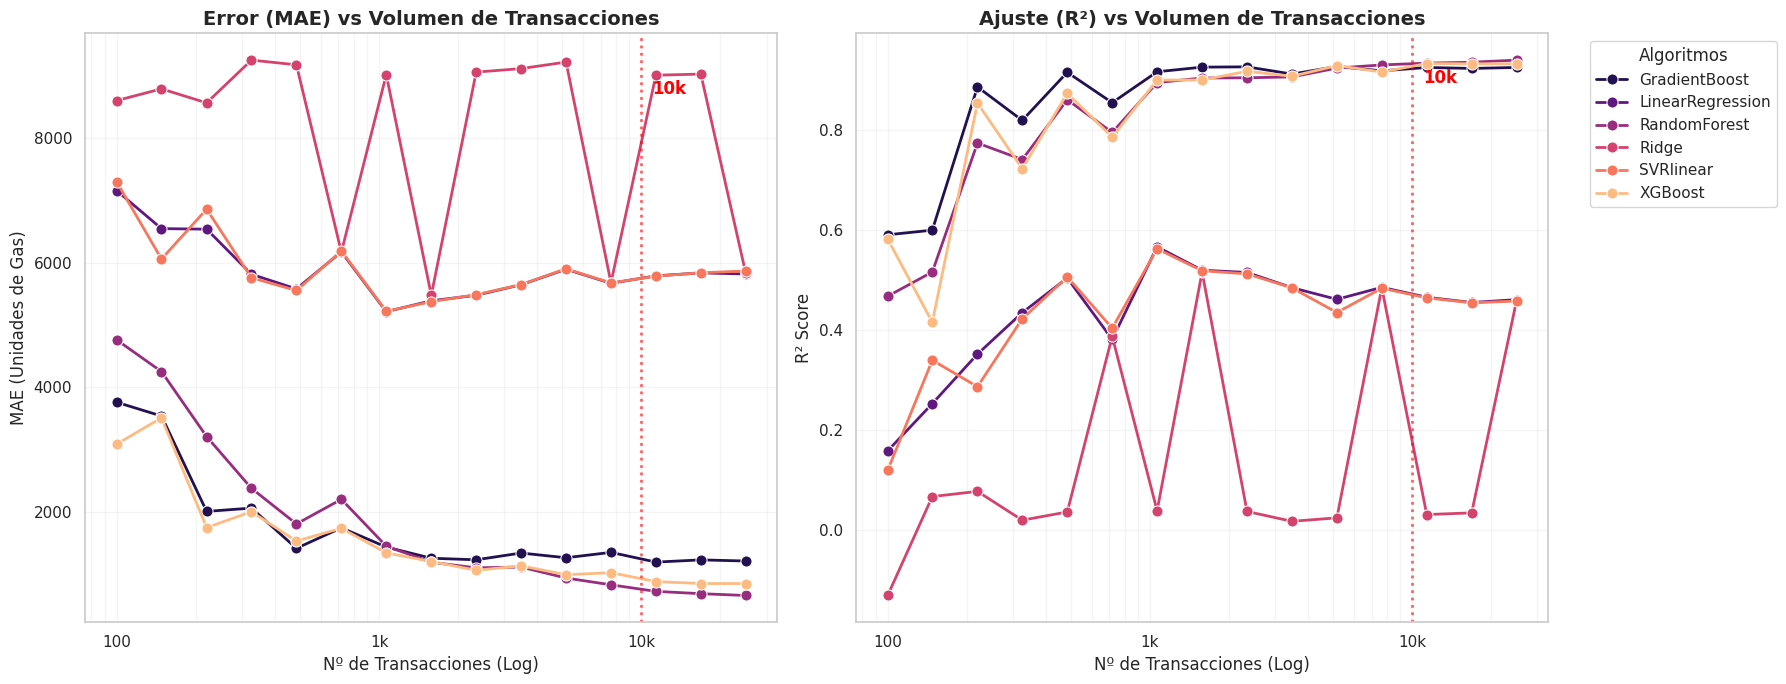

In [144]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

k_formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}')

sns.lineplot(
    ax=axes[0],
    data=df_all, 
    x='n_transactions', 
    y='mae', 
    hue='modelo', 
    marker='o', 
    markersize=8,
    linewidth=2, 
    palette='magma'
)

axes[0].set_xscale('log')
axes[0].xaxis.set_major_formatter(k_formatter)
axes[0].set_title('Error (MAE) vs Volumen de Transacciones', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MAE (Unidades de Gas)', fontsize=12)

sns.lineplot(
    ax=axes[1],
    data=df_all, 
    x='n_transactions', 
    y='r2', 
    hue='modelo', 
    marker='o', 
    markersize=8,
    linewidth=2, 
    palette='magma'
)

axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(k_formatter)
axes[1].set_title('Ajuste (R²) vs Volumen de Transacciones', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R² Score', fontsize=12)
ç-
for ax in axes:
    ax.set_xlabel('Nº de Transacciones (Log)', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.2)
       
    ax.axvline(x=t_min, color='red', linestyle=':', linewidth=2, alpha=0.6)
    #ax.axvline(x=t_max, color='blue', linestyle=':', linewidth=2, alpha=0.6)
    #ax.axvline(x=200000, color='green', linestyle=':', linewidth=2, alpha=0.6)
    
    ax.text(t_min * 1.1, ax.get_ylim()[1] * 0.9, f'{t_min/1000:g}k', color='red', fontweight='bold')

axes[0].get_legend().remove() 
plt.legend(title='Algoritmos', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Ejecutar para estudio con valores altos

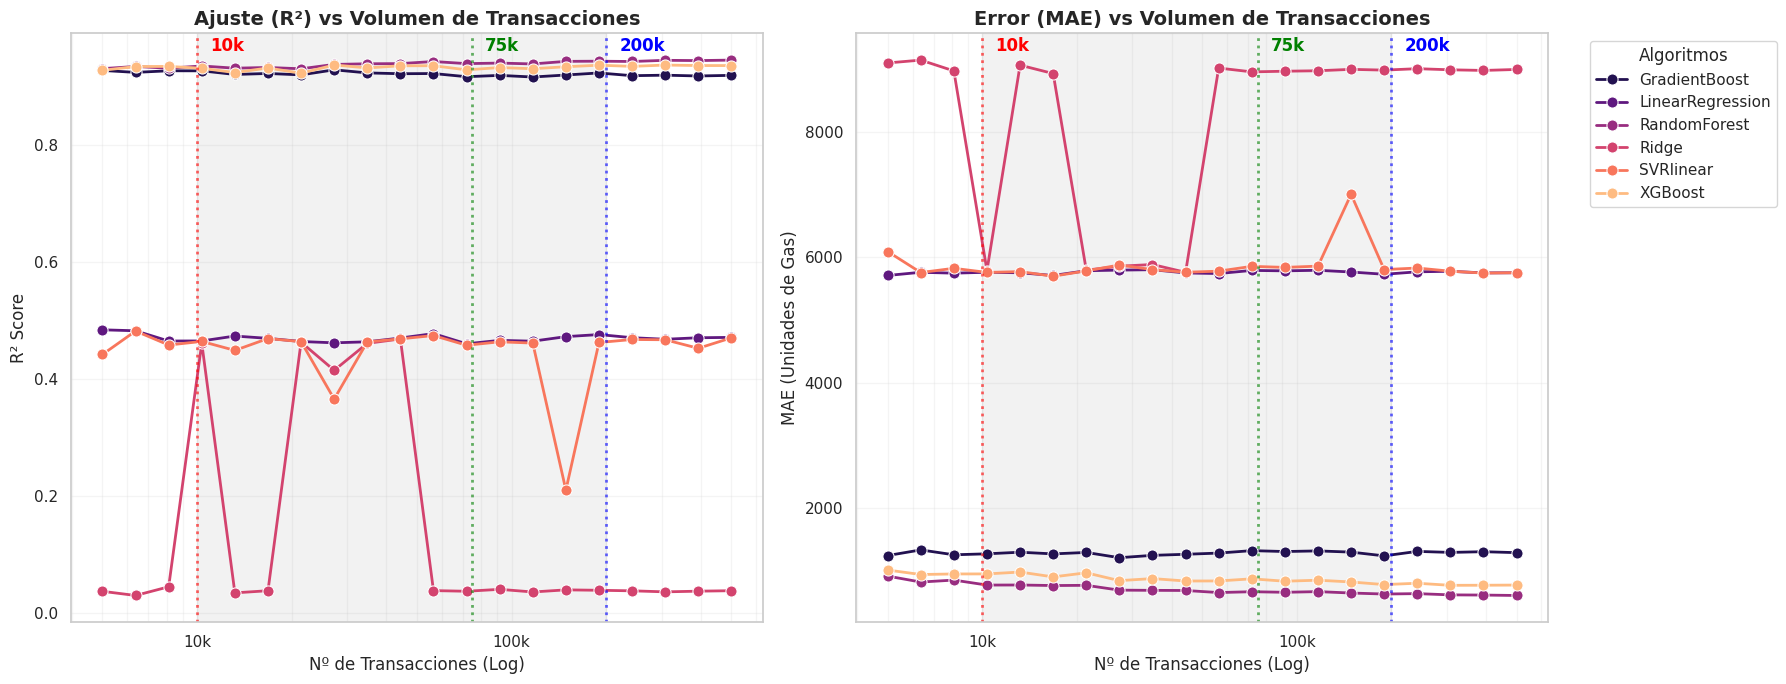

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

k_formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}')

sns.lineplot(
    ax=axes[0],
    data=df_all, 
    x='n_transactions', 
    y='r2', 
    hue='modelo', 
    marker='o', 
    markersize=8,
    linewidth=2, 
    palette='magma'
)

axes[0].set_xscale('log')
axes[0].xaxis.set_major_formatter(k_formatter)
axes[0].set_title('Ajuste (R²) vs Volumen de Transacciones', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12)

sns.lineplot(
    ax=axes[1],
    data=df_all, 
    x='n_transactions', 
    y='mae', 
    hue='modelo', 
    marker='o', 
    markersize=8,
    linewidth=2, 
    palette='magma'
)

axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(k_formatter)
axes[1].set_title('Error (MAE) vs Volumen de Transacciones', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE (Unidades de Gas)', fontsize=12)

for ax in axes:
    ax.set_xlabel('Nº de Transacciones (Log)', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    ax.axvspan(t_min, t_max, color='gray', alpha=0.1)
    
    ax.axvline(x=t_min, color='red', linestyle=':', linewidth=2, alpha=0.6)
    ax.axvline(x=t_max, color='blue', linestyle=':', linewidth=2, alpha=0.6)
    ax.axvline(x=75000, color='green', linestyle=':', linewidth=2, alpha=0.6)
    
    ax.text(t_min * 1.1, ax.get_ylim()[1] * 0.97, f'{t_min/1000:g}k', color='red', fontweight='bold')
    ax.text(t_max * 1.1, ax.get_ylim()[1] * 0.97, f'{t_max/1000:g}k', color='blue', fontweight='bold')
    ax.text(75000 * 1.1, ax.get_ylim()[1] * 0.97, f'{75000/1000:g}k', color='green', fontweight='bold')

axes[0].get_legend().remove() 
plt.legend(title='Algoritmos', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Estudio en general de modelos de predicción

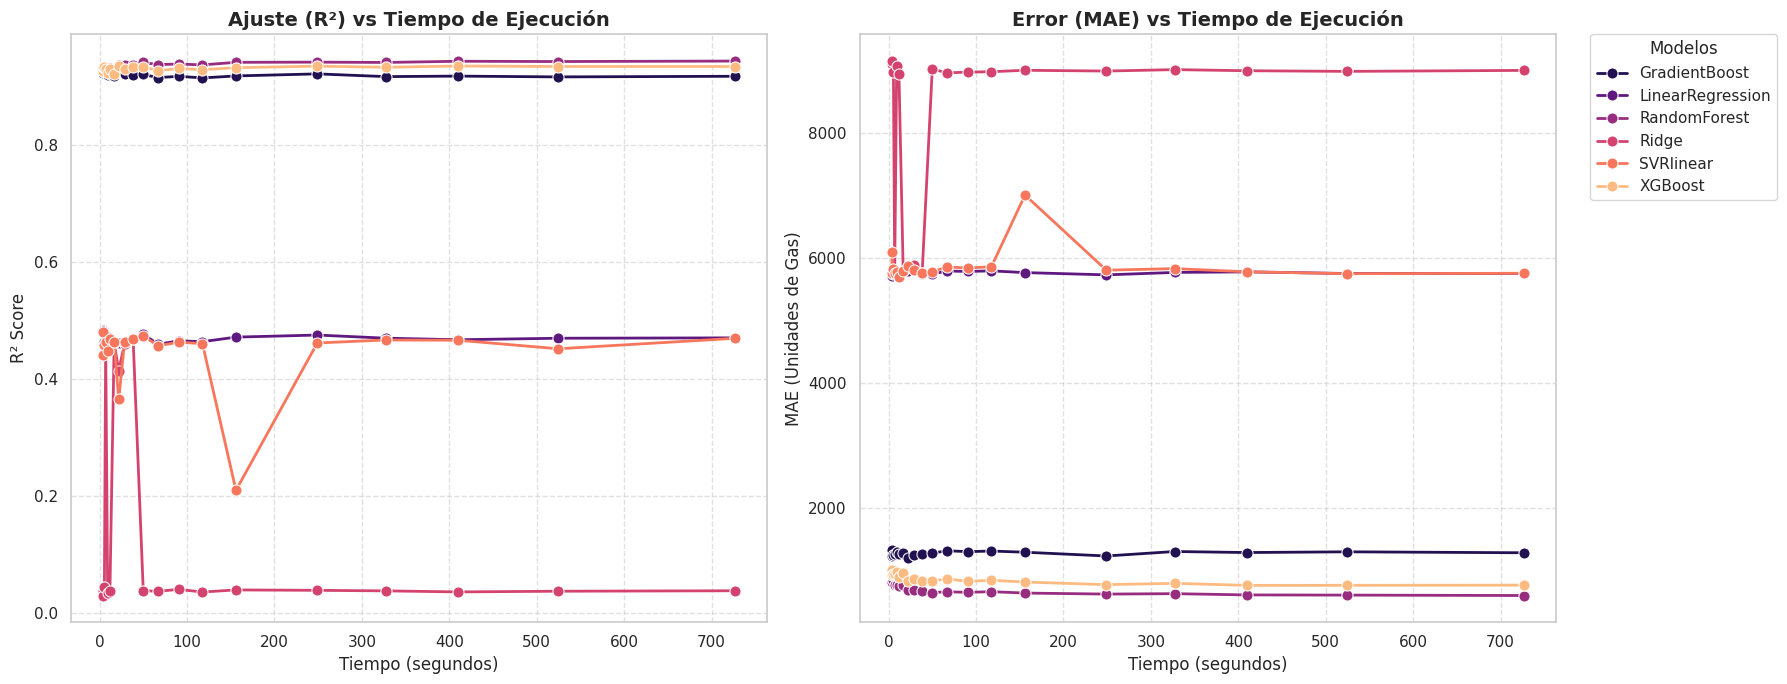

In [12]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))  # 1 fila, 2 columnas

sns.lineplot(
    ax=axes[0],
    data=df_all, 
    x='tiempo', 
    y='r2', 
    hue='modelo', 
    marker='o', 
    markersize=8,
    linewidth=2, 
    palette='magma'
)

# axes[1].set_xscale('log') 

axes[0].set_title('Ajuste (R²) vs Tiempo de Ejecución', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tiempo (segundos)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

sns.lineplot(
    ax=axes[1],
    data=df_all, 
    x='tiempo', 
    y='mae', 
    hue='modelo', 
    marker='o', 
    markersize=8,
    linewidth=2, 
    palette='magma'
)

axes[1].set_title('Error (MAE) vs Tiempo de Ejecución', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tiempo (segundos)', fontsize=12)
axes[1].set_ylabel('MAE (Unidades de Gas)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

if axes[0].get_legend():
    axes[0].get_legend().remove()

plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

In [ ]:
#plt.axvspan(t_min, t_max, color='green', alpha=0.1, label= f'Franja {t_min/1000:g}k-{t_max/1000:g}k')
#plt.axvline(x=t_min, color='green', linestyle='--', linewidth=1, alpha=0.5)
#plt.axvline(x=t_max, color='green', linestyle='--', linewidth=1, alpha=0.5)

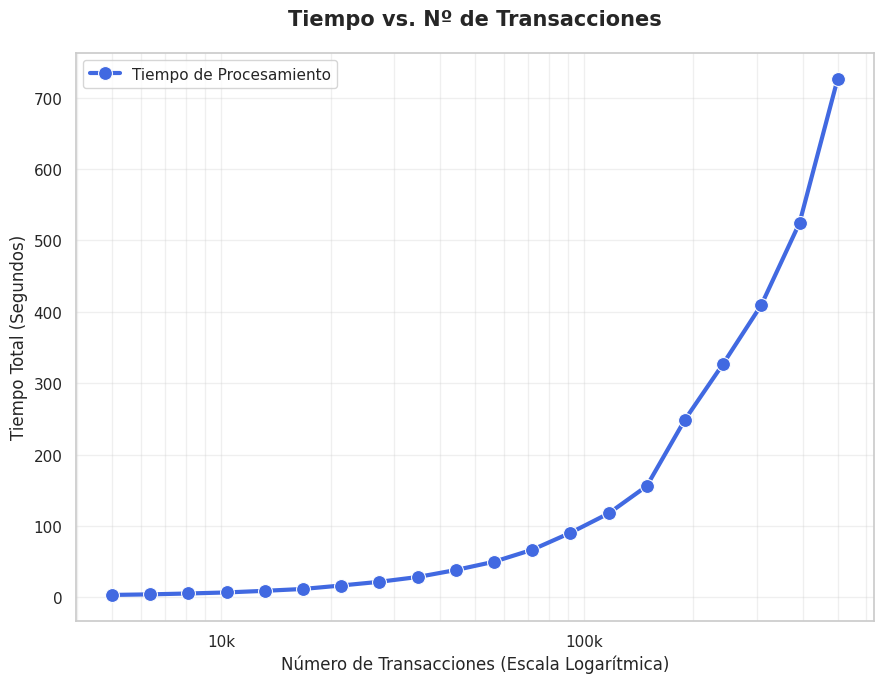

In [11]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 7)) 

sns.lineplot(
    data=df_all, 
    x='n_transactions', 
    y='tiempo', 
    color='royalblue',      
    marker='o',              
    linewidth=3, 
    markersize=10,
    label='Tiempo de Procesamiento'
)

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))

plt.title('Tiempo vs. Nº de Transacciones', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Número de Transacciones (Escala Logarítmica)', fontsize=12)
plt.ylabel('Tiempo Total (Segundos)', fontsize=12)
#plt.axvline(x=t_min, color='green', linestyle='--', linewidth=1, alpha=0.5)
#plt.axvline(x=t_max, color='green', linestyle='--', linewidth=1, alpha=0.5)

plt.grid(True, which="both", ls="-", alpha=0.3)

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()